# Script for Kmodes clustering model application on dataset (derived from knowledge graph)

##### Author: Shakira Agata

#### Section 1: System preparation

**Step 1.** The following packages are installed and loaded.

In [1]:
!pip install openpyxl
!pip install -U scikit-learn
!pip install pandas
!pip install -U matplotlib
!pip install kmodes
!pip install plotly

In [2]:
import pandas as pd
import plotly.express as px

In [3]:
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from kmodes.kmodes import KModes
from sklearn.preprocessing import OneHotEncoder

#### Section 2: Dataset loading

**Step 2.** Here, we load the dataset and check it.

In [4]:
df = pd.read_excel("C:/Users/shaki/Downloads/Table-overview.xlsx")
df

,ID (KEID),Name (KEtitle),Group,Type,KE level of organisation,Cell/organ term,WPtitle,Confidence score,Causative/responsive
0,https://identifiers.org/aop.events/486,systemic inflammation leading to hepatic steat...,Liver,MIE,Organ,Not specified,Overview of proinflammatory and profibrotic me...,Medium,Responsive
1,https://identifiers.org/aop.events/875,"Binding of agonist, Ionotropic glutamate recep...",Brain,MIE,Molecular,Neuron,Neuroinflammation and glutamatergic signaling,Medium,Other
2,https://identifiers.org/aop.events/2007,Non-coding RNA expression profile alteration,Lung,MIE,Molecular,Not specified,miRNAs involved in DNA damage response,Medium,Causative
3,https://identifiers.org/aop.events/2007,Non-coding RNA expression profile alteration,Lung,MIE,Molecular,Not specified,miRNA regulation of DNA damage response,Medium,Other
4,https://identifiers.org/aop.events/1495,Substance interaction with the lung resident c...,Lung,MIE,Molecular,Eukaryotic cell,Cytosolic DNA-sensing pathway,High,Responsive
...,...,...,...,...,...,...,...,...,...
287,https://identifiers.org/aop.events/352,"N/A, Neurodegeneration",Brain,KE,Tissue,Brain,Oxidative stress response,High,Causative
288,https://identifiers.org/aop.events/352,"N/A, Neurodegeneration",Brain,KE,Tissue,Brain,Apoptosis modulation and signaling,High,Causative
289,https://identifiers.org/aop.events/352,"N/A, Neurodegeneration",Brain,KE,Tissue,Brain,Apoptosis,High,Causative
290,https://identifiers.org/aop.events/352,"N/A, Neurodegeneration",Brain,KE,Tissue,Brain,BDNF-TrkB signaling,High,Causative


In [5]:
features = df.drop(columns=["ID (KEID)"])

#### Section 3: K-mode clustering application and visualisation

**Step 3.** Now, we remove the null rows from the dataset and use the elbow curve method to assess which number of cluster is best to select.

In [6]:
DF = features.dropna()

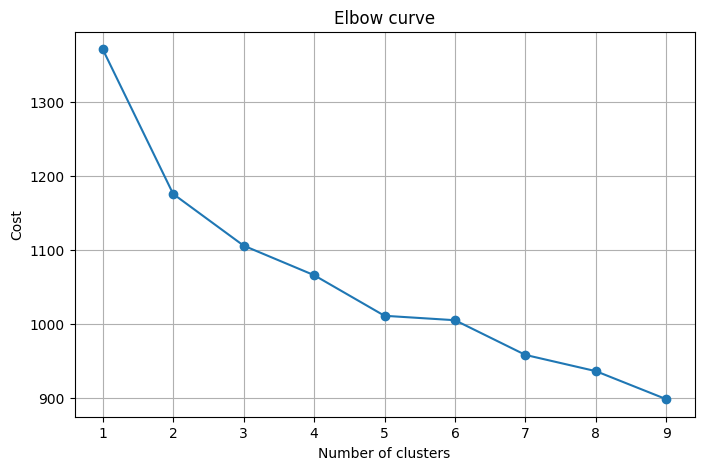

In [7]:
costs = []
K = range(1, 10) 

for k in K:
    km = KModes(n_clusters=k, init="random", n_init=5, verbose=0)
    km.fit_predict(DF)  
    costs.append(km.cost_)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(K, costs, marker='o')
plt.title('Elbow curve')
plt.xlabel('Number of clusters')
plt.ylabel('Cost')
plt.grid(True)
plt.show()

**Step 4.** The desired number of clusters appears to be 3 so this number is selected for the Kmodes model.

In [8]:
km = KModes(n_clusters=3, init='Huang', n_init=5, verbose=1)
clusters = km.fit_predict(DF)
DF1 = DF.copy()
DF1['Cluster'] = clusters

Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 46, cost: 1135.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 2, iteration: 1/100, moves: 59, cost: 1119.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 3, iteration: 1/100, moves: 85, cost: 1160.0
Run 3, iteration: 2/100, moves: 38, cost: 1144.0
Run 3, iteration: 3/100, moves: 19, cost: 1144.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 4, iteration: 1/100, moves: 8, cost: 1159.0
Run 4, iteration: 2/100, moves: 0, cost: 1159.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 5, iteration: 1/100, moves: 72, cost: 1147.0
Run 5, iteration: 2/100, moves: 10, cost: 1147.0
Best run was number 2


**Step 5**. Lastly, the clusters are visualized.

In [9]:
encoder = OneHotEncoder()
encoded_data = encoder.fit_transform(DF1.drop('Cluster', axis=1))
pca = PCA(n_components=2)
reduced = pca.fit_transform(encoded_data.toarray())

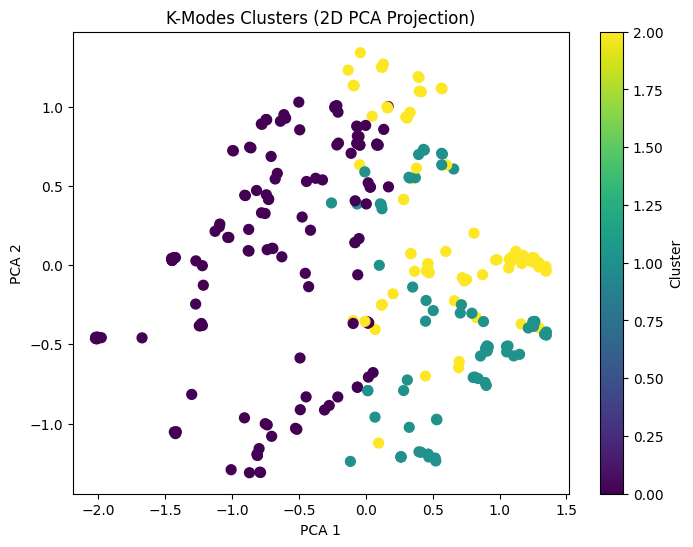

In [10]:
plt.figure(figsize=(8, 6))
plt.scatter(reduced[:, 0], reduced[:, 1], c=DF1['Cluster'], cmap='viridis', s=50)
plt.title("K-Modes Clusters (2D PCA Projection)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.colorbar(label='Cluster')
plt.show()

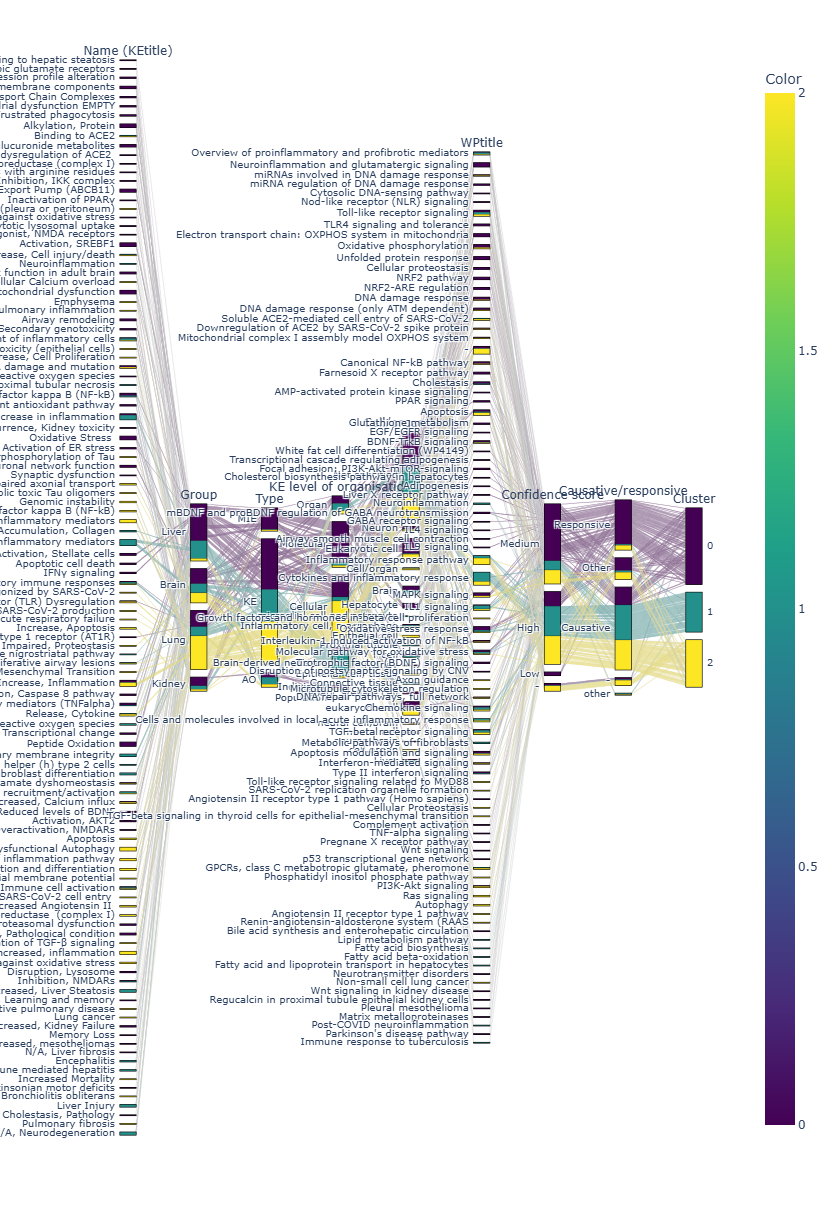

In [11]:
DF1['Cluster'] = DF1['Cluster'].astype(str)
cluster_codes = {label: i for i, label in enumerate(DF1['Cluster'].unique())}
DF1['Color'] = DF1['Cluster'].map(cluster_codes)
fig = px.parallel_categories(
    DF1,
    dimensions=[*DF1.columns[:-2], 'Cluster'],
    width=2000,   
    height=1200,
    color="Color",
    color_continuous_scale=px.colors.sequential.Viridis
)
fig.show()